# 🎧 Emotion-Aware Playlist & Quote Recommender
**End-to-end NLP project** - detects emotion in text with a fine-tuned transformer, then recommends songs + quotes.

**Pipeline:** Data → EDA → Baseline (TF-IDF + LogReg) → Fine-tune DistilBERT → Evaluate → Recommender (with *Match mood* / *Lift mood* modes) → Gradio demo

**Kaggle setup:** Settings → Accelerator = **GPU T4 x2 (or P100)**, Internet = **ON**.

In [1]:
!pip install -q datasets evaluate gradio
import warnings, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
warnings.filterwarnings('ignore')
print('GPU available:', torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00
GPU available: True


## 1. Data
We use the `dair-ai/emotion` dataset (~20k tweets, 6 emotions).

In [2]:
from datasets import load_dataset
ds = load_dataset('dair-ai/emotion')
labels = ds['train'].features['label'].names
print(ds); print(labels)
train_df, val_df, test_df = [pd.DataFrame(ds[s]) for s in ['train','validation','test']]
train_df.head()

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [3]:
# ===== TEXT NORMALIZATION BLOCK (paste after the Data cell) =====
import re, html
from datasets import DatasetDict

CONTRACTIONS = {"can't":"cannot","won't":"will not","n't":" not","'re":" are","'ve":" have",
                "'ll":" will","'d":" would","'m":" am","i'm":"i am","'s":" is"}
EMOJI_MAP = {'😢':' sad ','😭':' crying ','😡':' angry ','😠':' angry ','😂':' laughing ','😊':' happy ',
             '😄':' happy ','😍':' love ','❤️':' love ','😨':' scared ','😱':' shocked ','😮':' surprised '}

def normalize(text):
    t = html.unescape(str(text)).lower()
    for e, w in EMOJI_MAP.items(): t = t.replace(e, w)          # emojis -> words
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)                 # remove URLs
    t = re.sub(r'@\w+', ' ', t)                                  # remove @mentions
    t = re.sub(r'#(\w+)', r'\1', t)                              # #happy -> happy
    for c, r in CONTRACTIONS.items(): t = t.replace(c, r)        # expand contractions
    t = re.sub(r'(.)\1{2,}', r'\1\1', t)                         # sooooo -> soo
    t = re.sub(r"[^a-z0-9\s!?.,']", ' ', t)                      # drop odd symbols, keep ! ? (emotion cues)
    return re.sub(r'\s+', ' ', t).strip()                        # fix whitespace

# 1) Normalize the dataset -> baseline, EDA, training, evaluation all use it automatically
ds = DatasetDict({s: ds[s].map(lambda b: {'text': [normalize(x) for x in b['text']]}, batched=True) for s in ds})
train_df, val_df, test_df = [pd.DataFrame(ds[s]) for s in ['train', 'validation', 'test']]

# 2) Make the tokenizer normalize raw strings too -> the demo input gets cleaned automatically
from transformers import PreTrainedTokenizerBase
if not hasattr(PreTrainedTokenizerBase, '_orig_call'):
    PreTrainedTokenizerBase._orig_call = PreTrainedTokenizerBase.__call__
    def _norm_call(self, text=None, *a, **k):
        if isinstance(text, str): text = normalize(text)
        elif isinstance(text, (list, tuple)) and text and isinstance(text[0], str):
            text = [normalize(x) for x in text]
        return PreTrainedTokenizerBase._orig_call(self, text, *a, **k)
    PreTrainedTokenizerBase.__call__ = _norm_call

# Before/after demo (great for slides)
for s in ["I'm sooooo HAPPY!!! 😍 check https://t.co/xyz @john #blessed",
          "I can't believe they didn't call me 😭😭"]:
    print('BEFORE:', s); print('AFTER :', normalize(s), '\n')

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

BEFORE: I'm sooooo HAPPY!!! 😍 check https://t.co/xyz @john #blessed
AFTER : i am soo happy!! love check blessed 

BEFORE: I can't believe they didn't call me 😭😭
AFTER : i cannot believe they did not call me crying crying 



## 2. Exploratory Data Analysis

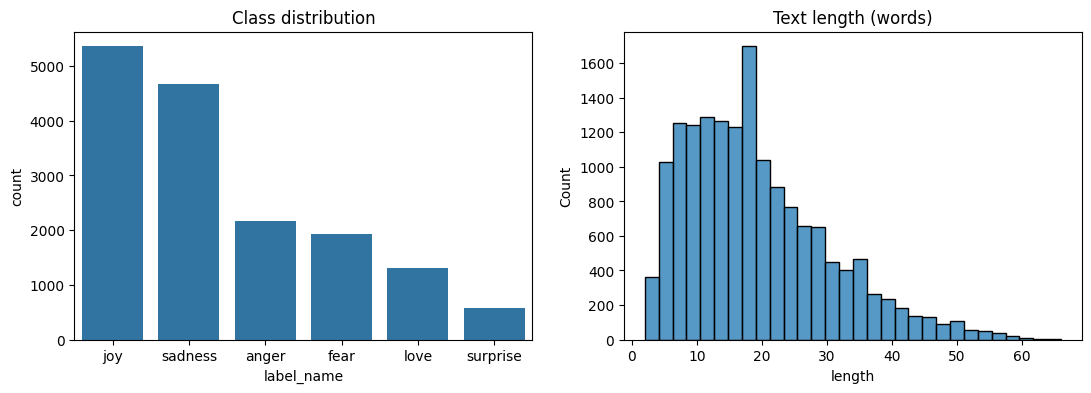

In [4]:
train_df['label_name'] = train_df['label'].map(lambda i: labels[i])
train_df['length'] = train_df['text'].str.split().str.len()
fig, ax = plt.subplots(1,2, figsize=(13,4))
sns.countplot(data=train_df, x='label_name', order=train_df.label_name.value_counts().index, ax=ax[0]); ax[0].set_title('Class distribution')
sns.histplot(train_df['length'], bins=30, ax=ax[1]); ax[1].set_title('Text length (words)')
plt.show()

## 3. Baseline: TF-IDF + Logistic Regression

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True)
Xtr = vec.fit_transform(train_df.text); Xte = vec.transform(test_df.text)
lr = LogisticRegression(max_iter=1000, C=5).fit(Xtr, train_df.label)
pred_lr = lr.predict(Xte)
base_acc, base_f1 = accuracy_score(test_df.label, pred_lr), f1_score(test_df.label, pred_lr, average='macro')
print(f'Baseline  acc={base_acc:.4f}  macro-F1={base_f1:.4f}')

Baseline  acc=0.8625  macro-F1=0.7965


## 4. Fine-tune DistilBERT (≈5–8 min on a T4)

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
MODEL = 'distilbert-base-uncased'
tok = AutoTokenizer.from_pretrained(MODEL)
enc = ds.map(lambda b: tok(b['text'], truncation=True, max_length=64), batched=True)
id2label = {i:l for i,l in enumerate(labels)}; label2id = {l:i for i,l in id2label.items()}
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=len(labels), id2label=id2label, label2id=label2id)

def metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {'accuracy': accuracy_score(p.label_ids, preds), 'macro_f1': f1_score(p.label_ids, preds, average='macro')}

args = TrainingArguments(output_dir='emotion_model', num_train_epochs=3, per_device_train_batch_size=32,
    per_device_eval_batch_size=64, learning_rate=5e-5, weight_decay=0.01, eval_strategy='epoch',
    save_strategy='epoch', load_best_model_at_end=True, metric_for_best_model='macro_f1',
    fp16=torch.cuda.is_available(), report_to='none', logging_steps=100)
trainer = Trainer(model=model, args=args, train_dataset=enc['train'], eval_dataset=enc['validation'],
    data_collator=DataCollatorWithPadding(tok), compute_metrics=metrics)
trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.577750,0.381711,0.926000,0.899706
2,0.290248,0.275853,0.938000,0.915610
3,0.178422,0.260460,0.944500,0.919409


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=750, training_loss=0.5064797592163086, metrics={'train_runtime': 167.3907, 'train_samples_per_second': 286.754, 'train_steps_per_second': 4.481, 'total_flos': 695967121640448.0, 'train_loss': 0.5064797592163086, 'epoch': 3.0})

## 5. Evaluation

              precision    recall  f1-score   support

     sadness      0.971     0.969     0.970       581
         joy      0.938     0.961     0.950       695
        love      0.845     0.786     0.814       159
       anger      0.933     0.909     0.921       275
        fear      0.861     0.942     0.900       224
    surprise      0.872     0.621     0.726        66

    accuracy                          0.929      2000
   macro avg      0.903     0.865     0.880      2000
weighted avg      0.929     0.929     0.928      2000



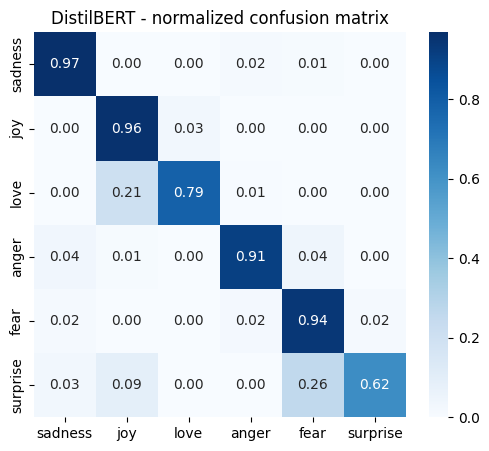

                     Model  Accuracy  Macro-F1
0          TF-IDF + LogReg    0.8625    0.7965
1  DistilBERT (fine-tuned)    0.9290    0.8800


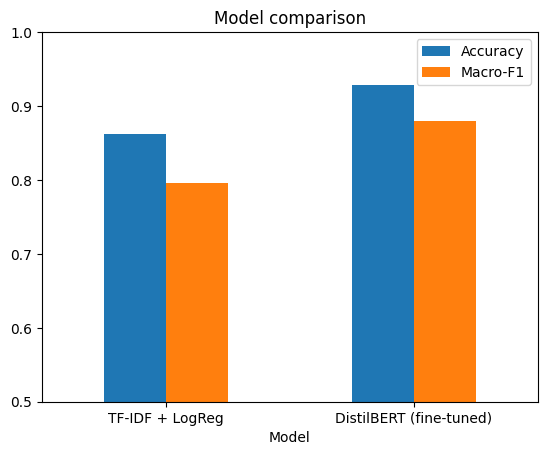

In [7]:
out = trainer.predict(enc['test'])
pred_bert = out.predictions.argmax(1)
print(classification_report(test_df.label, pred_bert, target_names=labels, digits=3))
bert_acc, bert_f1 = accuracy_score(test_df.label, pred_bert), f1_score(test_df.label, pred_bert, average='macro')

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_df.label, pred_bert, normalize='true')
plt.figure(figsize=(6,5)); sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('DistilBERT - normalized confusion matrix'); plt.show()

cmp = pd.DataFrame({'Model':['TF-IDF + LogReg','DistilBERT (fine-tuned)'],'Accuracy':[base_acc,bert_acc],'Macro-F1':[base_f1,bert_f1]})
print(cmp.round(4)); cmp.set_index('Model').plot.bar(rot=0, ylim=(0.5,1)); plt.title('Model comparison'); plt.show()

In [8]:
trainer.save_model('final_emotion_model'); tok.save_pretrained('final_emotion_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('final_emotion_model/tokenizer_config.json',
 'final_emotion_model/tokenizer.json')

## 6. Recommendation engine
Two modes: **Match my mood** (songs that fit how you feel) and **Lift my mood** (songs that move you toward a positive state).

In [9]:
random.seed(42)
SONGS = {
 'joy':     ['Happy - Pharrell Williams','Badtameez Dil - Pritam','Gallan Goodiyan - Shankar-Ehsaan-Loy','Good as Hell - Lizzo','Walking on Sunshine - Katrina & The Waves','Ilahi - Pritam'],
 'love':    ['Perfect - Ed Sheeran','Tum Hi Ho - Arijit Singh','Raabta - Arijit Singh','Thinking Out Loud - Ed Sheeran','Pehla Nasha - Udit Narayan','All of Me - John Legend'],
 'sadness': ['Someone Like You - Adele','Channa Mereya - Arijit Singh','Fix You - Coldplay','Agar Tum Saath Ho - Alka Yagnik','Let Her Go - Passenger','Tum Se Hi - Mohit Chauhan'],
 'anger':   ['Lose Yourself - Eminem','Believer - Imagine Dragons','Sultan - Sukhwinder Singh','Break Stuff - Limp Bizkit','Zinda - Siddharth Mahadevan','In the End - Linkin Park'],
 'fear':    ['Brave - Sara Bareilles','Kun Faya Kun - A.R. Rahman','Don\'t Stop Believin\' - Journey','Safe and Sound - Capital Cities','Phir Se Ud Chala - Mohit Chauhan','Weightless - Marconi Union'],
 'surprise':['Uptown Funk - Bruno Mars','Kala Chashma - Badshah','Can\'t Stop the Feeling - Justin Timberlake','Levitating - Dua Lipa','Gulabi Aankhen - Sanam','Shake It Off - Taylor Swift'],
}
QUOTES = {
 'joy':     ['Hold on to this feeling - joy shared is joy doubled.','Today is proof that good days exist. Remember it on the hard ones.','Happiness looks good on you. Keep going.'],
 'love':    ['Love is not found, it is built, one small kindness at a time.','The people who care for you are your real wealth.','Say the kind thing out loud today.'],
 'sadness': ['It is okay to not be okay. This feeling will pass, even if slowly.','Rest is productive too. Be gentle with yourself.','Every storm runs out of rain eventually.'],
 'anger':   ['Pause. Breathe. Your calm is your superpower.','Anger is energy - point it at the problem, not the person.','You do not have to answer every provocation.'],
 'fear':    ['Courage is taking the next small step while still afraid.','You have survived every hard day so far. Your record is perfect.','Fear shrinks when you face it one step at a time.'],
 'surprise':['Life loves to plot-twist. Stay curious.','Unexpected moments are where stories begin.','Embrace the unplanned - it often leads somewhere wonderful.'],
}
LIFT_MAP = {'sadness':'joy','anger':'fear','fear':'joy','joy':'joy','love':'love','surprise':'joy'}  # target emotion for 'lift' mode
LIFT_MAP['anger'] = 'love'  # calm anger with warm / soothing music

emo_pipe = None
def predict_emotions(text):
    inputs = tok(text, return_tensors='pt', truncation=True, max_length=64).to(model.device)
    with torch.no_grad(): logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    return {labels[i]: float(probs[i]) for i in range(len(labels))}

def recommend(text, mode='Match my mood', n_songs=3):
    probs = predict_emotions(text)
    top = max(probs, key=probs.get)
    target = top if mode=='Match my mood' else LIFT_MAP[top]
    songs = random.sample(SONGS[target], n_songs)
    quote = random.choice(QUOTES[target])
    return top, probs, songs, quote

model.eval()
for t in ['I failed my exam and I feel so empty','I just got my dream job!!','I cannot believe they lied to my face']:
    print(t, '->', recommend(t)[0])

I failed my exam and I feel so empty -> sadness
I just got my dream job!! -> joy
I cannot believe they lied to my face -> anger


## 7. Interactive demo (Gradio)

In [10]:
import gradio as gr

def app_fn(text, mode):
    if not text.strip():
        return 'Please type something.', {}, '', ''
    top, probs, songs, quote = recommend(text, mode)
    emoji = {'joy':'😄','love':'❤️','sadness':'😢','anger':'😠','fear':'😨','surprise':'😮'}[top]
    return (f'{emoji} Detected emotion: **{top.upper()}**', probs,
            '\n'.join(f'🎵 {s}' for s in songs), f'💬 {quote}')

demo = gr.Interface(
    fn=app_fn,
    inputs=[gr.Textbox(lines=3, label='How are you feeling? Write a sentence...'),
            gr.Radio(['Match my mood', 'Lift my mood'], value='Match my mood', label='Mode')],
    outputs=[gr.Markdown(), gr.Label(num_top_classes=6, label='Emotion probabilities'),
             gr.Textbox(label='Playlist'), gr.Textbox(label='Quote for you')],
    title='🎧 Emotion-Aware Playlist & Quote Recommender')
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b5e8ae10b8eb988d54.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Limitations & Future Work
- Dataset is English tweets with 6 emotions; real moods are more nuanced (multi-label).
- Song lists are hand-curated; could be replaced by Spotify API / audio features (valence, energy).
- Add Hinglish support via `xlm-roberta`, and multi-emotion blending using the probability vector.
- Add a user-feedback loop to personalise recommendations.